# Homework 2

### Instructions
Download this jupyer notebook (button at the top of the page or download from the Github repository). Provide your answers as Markdown text, Python code, and/or produce plots as appropriate. The notebook should run all the cells in order without errors.  
Submit both the `.ipynb` and a `.pdf` to Canvas.

Make sure the `.pdf` has all the relevant outputs showing. To save as `.pdf` you can first export the notebook as `.html`, open it in a browers and then "Print to PDF". 

**NOTE:** As we will be sharing the files for peer grading, please keep your submission anonymous.

In [1]:
import abc
from typing import Callable
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import functools
import cvxpy as cp
import functools
from ipywidgets import interact


# Problem 1 (Dynamic programming)


# Problem 2 (Dynamic programming - stochastic)

# Problem 3 (Value iteration)
*(This problem is adapted from Stanford AA203 course)*

In this problem, you will implement value iteration to compute the value function for a rescue drone that needs to deliver aid to a goal state while avoiding regions with fire and uncertain wind conditions.

The world is represented as an $n \times n$ grid, i.e., the state space is
$$ \mathcal{S}  := \lbrace(x_1, x_2) \in \mathbb{Z}_+^2 \mid | x_1, x_2 \in \lbrace 0, 1 . . . , n − 1\rbrace\rbrace.$$

In these coordinates, $(0, 0)$ represents the bottom left corner of the map and $(n−1, n−1)$ represents the top right corner of the map. From any location $x = (x_1, x_2) \in \mathcal{S}$, the drone has four possible directions it can move in, i.e.,

$$ \mathcal{A}:= \lbrace \texttt{up}, \texttt{down}, \texttt{left}, \texttt{right} \rbrace.$$

The corresponding state changes for each action are:
- $\texttt{up}: (x_1, x_2) \mapsto (x_1, x_2+1)$ 
- $\texttt{down}: (x_1, x_2) \mapsto (x_1, x_2-1)$ 
- $\texttt{left}: (x_1, x_2) \mapsto (x_1-1, x_2)$ 
- $\texttt{right}: (x_1, x_2) \mapsto (x_1+1, x_2)$ 

There is a storm centered at $x_\mathrm{eye} \in \mathcal{S}$. The storm’s influence is strongest at its center and decays farther from the center according to the equation 

$$ \omega(x) = \exp\biggl( -\frac{\| x - x_\mathrm{eye}\|_2^2}{2\sigma^2}\biggr)$$

Given its current state $x$ and action $a$, the drone’s next state is determined as follows:
- With probability $\omega(x)$, the storm will cause the drone to move in a uniformly random direction.
- With probability $1 − \omega(x)$, the drone will move in the direction specified by the action.
- If the resulting movement would cause the drone to leave $\mathcal{S}$, then it will not move at all. For example, if the drone is on the right boundary of the map, then moving right will do nothing.

The quadrotor’s objective is to reach $x\mathrm{goal} \in \mathcal{S}$. If the drone reaches the goal state, then it receives a reward of 1, and a reward of 0 otherwise. Additionally, there are some states where there is a fire. If the drone reaches a state where there is a fire, then it receives a reward of -100. The reward of a trajectory in this infinite horizon problem is a discounted sum of the rewards earned in each timestep, with discount factor $\gamma \in (0, 1)$.

Below are some helper functions. Some are filled in, others you will you need to fill in yourself.

In [2]:
def _state_space(max_rows, max_columns):
    return [(i, j) for i in range(max_rows) for j in range(max_columns)]


def _reward(state, fire_states, goal_states, fire_value, goal_value):
    """
    Reward function for the grid world.
    Args:
        state: Current state (row, column).
        fire_states: List or set of fire states.
        goal_states: List or set of goal states.
        fire_value: Reward value for fire states.
        goal_value: Reward value for goal states.
    Returns:
        Reward value for the current state.
    """
    
    if state in goal_states:
        return goal_value
    elif state in fire_states:
        return fire_value
    else:
        return 0
    
def _transition_function(s, a, w=0, 
                        max_rows=20, # number of rows
                        max_columns=20, # number of columns
                        action_set=["down", "right", "up", "left"]):
    """
    Transition function for the grid world.
    Args:
        s: Current state (row, column).
        a: Action to take.
        w: Probability of taking the action.
        max_rows: Number of rows in the grid.
        max_columns: Number of columns in the
            grid.
        action_set: List of possible actions.
    Returns:
        New state after taking the action.
    """
    i,j = s
    if (np.random.rand(1) < w)[0]:
        a = np.random.choice(action_set)
    if a == "up":
        return (min(i+1, max_rows-1), j)
    if a == "right":
        return (i, min(j+1, max_columns-1))
    if a == "down":
        return (max(i-1, 0), j)
    if a == "left":
        return (i, max(j-1, 0))
    
def _compute_omega_probability(state, storm_eye, storm_sigma):
    """
    Computes the probability of a state being affected by a storm.
    Args:
        state: Current state (row, column).
        storm_eye: Center of the storm (row, column).
        storm_sigma: Standard deviation of the storm.
    Returns:
        Probability of the state being affected by the storm.
    """
    return np.exp(-((state[0] - storm_eye[0])**2 + (state[1] - storm_eye[1])**2) / (2 * storm_sigma**2))

#### Problem parameters

Given that the size of the grid is $20 \times 20$, $\sigma = 10$, $\gamma = 0.95$, $x_\mathrm{eye}=(15,15)$, and $x_\mathrm{goal} = (19,9)$, fill in the following functions to perform value iteration to find the optimal value function for the drone to navigate the storm. Recall that the value iteration repeats the Bellman update:

$$ V(x) \leftarrow \max_{a\in\mathcal{A}} \biggl( \sum_{x^\prime \in \mathcal{S}} p(x, a, x^\prime) (R(x^\prime) + \gamma V(x^\prime))\biggr)$$

In [3]:
# problem set up
max_rows, max_columns = 20, 20
fire_states = set([(10,10), (11,10), (10,11), (11,11)])
storm_eye = (13, 8)
storm_sigma = 5
goal_states = set([(19,9)])
gamma = 0.95
fire_value = -100
goal_value = 1
action_set=["down", "right", "up", "left"]


# fix the problem parameters in the functions to avoid passing them every time
state_space = functools.partial(_state_space, max_rows=max_rows, max_columns=max_columns)
reward = functools.partial(_reward, fire_states=fire_states, goal_states=goal_states, fire_value=fire_value, goal_value=goal_value)
transition_function = functools.partial(_transition_function, max_rows=max_rows, max_columns=max_columns, action_set=["up", "down", "left", "right"])
compute_omega_probability = functools.partial(_compute_omega_probability, storm_eye=storm_eye, storm_sigma=storm_sigma)



In [4]:
def probability_function(state, action, next_state, w, 
                          action_set=["down", "right", "up", "left"]):
    """
    Computes the probability of transitioning to a next state given the current state and action.
    Args:
        state: Current state (row, column).
        action: Action to take.
        next_state: Next state (row, column).
        w: Probability of taking random action.
        action_set: List of possible actions.
    Returns:
        Probability of transitioning to the next state.
    """
    deterministic_next_state = transition_function(state, action, w=0)
    
    return w / len(action_set) + (1 - w) * (deterministic_next_state == next_state)

def get_possible_next_states(state, action_set):
    """
    Returns the set of possible next states given the current state.
    Args:
        state: Current state (row, column).
    Returns:
        Set of possible next states.
    """
    return set([transition_function(state, action, w=0) for action in action_set])

def bellman_update(value, gamma, action_set):
    """
    Performs a Bellman update on the value function.
    Args:
        value: Current value function.
        gamma: Discount factor.
        action_set: List of possible actions.
    Returns:
        Updated value function and policy as a dictionary.
    """
    new_value = value.copy()
    policy = {}
    for state in state_space():
        w = compute_omega_probability(state)
        qs = []
        for action in action_set:
            qs.append(sum(probability_function(state, action, next_state, w=w) * (reward(next_state) + gamma * value[next_state]) for next_state in get_possible_next_states(state, action_set)))
        new_value[state] = max(qs)
        policy[state] = action_set[np.argmax(qs)]
    return new_value, policy
        
def simulate(start_state, policy, num_steps):
    states = [start_state]
    for _ in range(num_steps):
        action = policy[start_state]
        w = compute_omega_probability(start_state)
        next_state = transition_function(start_state, action, w=w)
        start_state = next_state
        states.append(start_state)
    return states

In [5]:
# Initialize the value function
V = np.zeros([max_rows, max_columns])
# keep list of value functions
Vs = [V]
dV = []
num_iterations = 40
for _ in range(num_iterations):
    # perform Bellman update
    V_new, policy = bellman_update(V, gamma, action_set)
    # store the new value function
    Vs.append(V_new)
    dV.append(np.abs(V_new - V).max())

    # check for convergence
    if np.abs(V_new - V).max() < 1e-3:
        print("Converged!")
        break
    # update the value function
    V = V_new
    

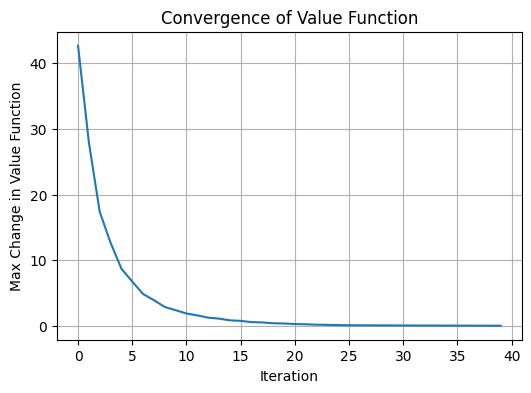

In [11]:
plt.figure(figsize=(6,4))
plt.plot(dV)
plt.title('Convergence of Value Function')
plt.xlabel('Iteration')
plt.ylabel('Max Change in Value Function')
plt.grid()

In [12]:
# compute the storm strength for each state for plotting later
storm_strength = np.zeros([max_rows, max_columns])
for state in state_space():
    storm_strength[state] = compute_omega_probability(state)
    

In [14]:
# visualize the value function and storm strength
@interact(iteration=(0,len(Vs)-1, 1))
def plot_value_function(iteration):
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(Vs[iteration], origin='lower', extent=[0, max_columns, 0, max_rows], cmap='viridis', interpolation='nearest')
    plt.colorbar(label='Value')
    plt.title('Value Function')
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.xticks(ticks=np.arange(0.5, max_columns, 1), labels=np.arange(0, max_columns))
    plt.yticks(ticks=np.arange(0.5, max_rows, 1), labels=np.arange(0, max_rows))
    plt.scatter(storm_eye[1] + 0.5, storm_eye[0] + 0.5, c='blue', s=100, label='Storm Eye')
    for fire_state in fire_states:
        plt.scatter(fire_state[1] + 0.5, fire_state[0] + 0.5, c='red', s=100)
    plt.scatter(fire_state[1] + 0.5, fire_state[0] + 0.5, c='red', s=100, label='Fire State')
    for goal_state in goal_states:
        plt.scatter(goal_state[1] + 0.5, goal_state[0] + 0.5, c='green', s=100, label='Goal State')
        
    # Overlay the policy
    for (row, col), action in policy.items():
        if action == "up":
            plt.text(col + 0.5, row + 0.5, '↑', ha='center', va='center', color='black', fontsize=8)
        elif action == "down":
            plt.text(col + 0.5, row + 0.5, '↓', ha='center', va='center', color='black', fontsize=8)
        elif action == "left":
            plt.text(col + 0.5, row + 0.5, '←', ha='center', va='center', color='black', fontsize=8)
        elif action == "right":
            plt.text(col + 0.5, row + 0.5, '→', ha='center', va='center', color='black', fontsize=8)
    plt.legend(loc='upper left')
    
    plt.subplot(1, 2, 2)
    plt.imshow(storm_strength, origin='lower', extent=[0, max_columns, 0, max_rows], cmap='viridis', interpolation='nearest')
    plt.colorbar(label='Storm Strength')
    plt.title('Storm Strength')
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.xticks(ticks=np.arange(0.5, max_columns, 1), labels=np.arange(0, max_columns))
    plt.yticks(ticks=np.arange(0.5, max_rows, 1), labels=np.arange(0, max_rows))
    plt.show()

interactive(children=(IntSlider(value=20, description='iteration', max=40), Output()), _dom_classes=('widget-i…

In [ ]:
# simulate a trajectory
start_state = (7, 7) # pick a starting state
num_steps = 50
trajectory = simulate(start_state, policy, num_steps)

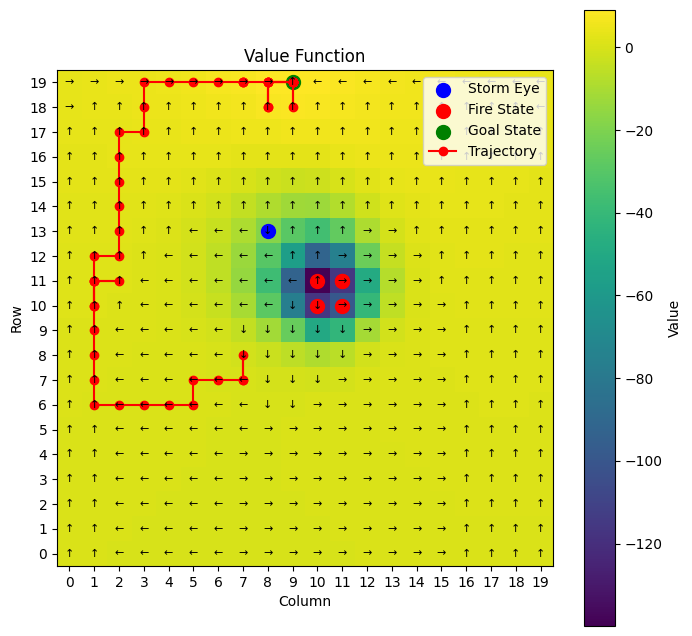

In [10]:
# Plot the trajectory
plt.figure(figsize=(8, 8))
plt.imshow(Vs[-1], origin='lower', extent=[0, max_columns, 0, max_rows], cmap='viridis', interpolation='nearest')
plt.colorbar(label='Value')
plt.title('Value Function')
plt.xlabel('Column')
plt.ylabel('Row')
plt.xticks(ticks=np.arange(0.5, max_columns, 1), labels=np.arange(0, max_columns))
plt.yticks(ticks=np.arange(0.5, max_rows, 1), labels=np.arange(0, max_rows))
plt.scatter(storm_eye[1] + 0.5, storm_eye[0] + 0.5, c='blue', s=100, label='Storm Eye')
for fire_state in fire_states:
    plt.scatter(fire_state[1] + 0.5, fire_state[0] + 0.5, c='red', s=100)
plt.scatter(fire_state[1] + 0.5, fire_state[0] + 0.5, c='red', s=100, label='Fire State')
for goal_state in goal_states:
    plt.scatter(goal_state[1] + 0.5, goal_state[0] + 0.5, c='green', s=100, label='Goal State')
    
# Overlay the policy
for (row, col), action in policy.items():
    if action == "up":
        plt.text(col + 0.5, row + 0.5, '↑', ha='center', va='center', color='black', fontsize=8)
    elif action == "down":
        plt.text(col + 0.5, row + 0.5, '↓', ha='center', va='center', color='black', fontsize=8)
    elif action == "left":
        plt.text(col + 0.5, row + 0.5, '←', ha='center', va='center', color='black', fontsize=8)
    elif action == "right":
        plt.text(col + 0.5, row + 0.5, '→', ha='center', va='center', color='black', fontsize=8)
plt.legend(loc='upper left')

# Plot the trajectory
trajectory_x = [state[1] + 0.5 for state in trajectory]
trajectory_y = [state[0] + 0.5 for state in trajectory]
plt.plot(trajectory_x, trajectory_y, marker='o', color='red', label='Trajectory')

plt.legend()
plt.show()

# Problem 4 (Linear Quadratic Regulator)

# Problem 5 (HJ reachability)

# Problem 6 (Trajectory optimization - sequential quadratic programming)

In this problem, you will explore sequential quadratic programming, and algorithm where you successively convexify your nonlinear trajectory optmization problem about a previous solution, and reduce the problem into a quadratic program.
Assuming the cost objective is already quadratic, the bulk of the convexification will be focused on linearizing the dynamics and constraints about a previous solution.

Below is an implementation of SQP with a dynamically extended simple car model avoiding *one* circular obstacle. You should read each line of the code; the following questions will be based on your understanding of the SQP algorithm and following implementation.

The dynamically extended simple car has the following dynamics:

$$
\begin{bmatrix}
\dot{x} \\ \dot{y} \\ \dot{\theta} \\ \dot{v}
\end{bmatrix}
= 
\begin{bmatrix}
v\cos\theta\\ v\sin\theta \\ \frac{v}{L}\tilde{\delta} \\ a
\end{bmatrix}, \qquad u = \begin{bmatrix} \tilde{\delta} \\ a \end{bmatrix} \: \text{where} \: \tilde{\delta} = \tan\delta
$$

Note: We have made the substitution $\tilde{\delta} = \tan\delta$ so that the system is control affine since the mapping is bijective over $(-\pi/2, \pi/2)$

Let $g(x; x_\mathrm{ob}, r)$ denote a function that measure how far away the state $x$ is from a circular obstacle centered at $x_\mathrm{ob}$ with radius $r$. 


In [246]:
import cvxpy as cp # import cvxpy

# in this problem, we will use the dynamaxsys library to import dynamical systems implemented in JAX: https://github.com/UW-CTRL/dynamaxsys
from dynamaxsys.simplecar import DynamicallyExtendedSimpleCar
from dynamaxsys.base import get_discrete_time_dynamics
from dynamaxsys.utils import linearize

In [95]:
# define the robot dynamics
wheelbase = 1.0
dt = 0.1
ct_robot_dynamics = DynamicallyExtendedSimpleCar(wheelbase=wheelbase) # robot dynamics
dt_robot_dynamics = get_discrete_time_dynamics(ct_robot_dynamics, dt=dt) # discrete time dynamics
state_dim = dt_robot_dynamics.state_dim
control_dim = dt_robot_dynamics.control_dim


In [ ]:
# some helper functions

# define obstacle function g(x) >= 0
# where g(x) is the distance from the obstacle
@jax.jit
def obstacle_constraint(state, obstacle, radius):
    return jnp.linalg.norm(state[:2] - obstacle[:2]) - radius

# function to simulate the discrete time dynamics given initial state and control sequence
@functools.partial(jax.jit, static_argnames=["dt_dynamics"])
def simulate_discrete_time_dynamics(dt_dynamics, state, controls, t0, dt):
    states = [state]
    t = t0
    for c in controls:
        state = dt_dynamics(state, c, t)
        states.append(state)
        t += dt
    return jnp.stack(states)

# jit the linearize constraint functions to make it run faster
linearize_obstacle = jax.jit(jax.vmap(jax.grad(obstacle_constraint), in_axes=[0, None, None]))

In [239]:
# set up the problem parameters
planning_horizon = 25 # length of the planning horizon
num_time_steps = 50 # number of time steps to simulate
num_sqp_iterations = 15 # number of SQP iterations
t = 0. # this doesn't affect anything, but a value is needed 

# control and velocity limits
v_max = 1.5
v_min = 0.
acceleration_max = 1.0
acceleration_min = -1.0
steering_max = 0.5
steering_min = -0.5

# obstacle parameters
obstacle_location = jnp.array([1.0, 0.0]) # obstacle location
obstacle_location2 = jnp.array([3.0, -0.5]) # obstacle location
obstacle_radius = 0.5 # obstacle radius
robot_radius = 0.1 # robot radius


## (a) The inner quadratic program problem

Take a close look at the following two cells. Let $x^\mathrm{prev}_t$ and $u^\mathrm{prev}_t$ denote the state and control at time $t$ from the *previous* SQP iteration.
Write out the exact quadratic program that is being solved at each SQP iteration. Keep variables/parameters in terms of their names and don't use their numerical values. For example, use $\beta_1$ instead of 0.2.


Additionally, describe what each term in the problem represents, and the expression for them. That is, define mathematically what they are using mathematical expressions, their role within the optimization problem, and describe in words the interpretation of them. 


Write the QP here....

$$ ... $$

In [240]:
# set up cvxpy problem variables and parameters
xs = cp.Variable([planning_horizon+1, state_dim])  # cvx variable for states
us = cp.Variable([planning_horizon, control_dim])  # cvx variable for controls
slack = cp.Variable(1) # slack variable to make sure the problem is feasible
As = [cp.Parameter([state_dim, state_dim]) for _ in range(planning_horizon)]  # parameters for linearized dynamics
Bs = [cp.Parameter([state_dim, control_dim]) for _ in range(planning_horizon)] # parameters for linearized dynamics
Cs = [cp.Parameter([state_dim]) for _ in range(planning_horizon)] # parameters for linearized dynamics

Gs = [cp.Parameter([state_dim]) for _ in range(planning_horizon+1)] # parameters for linearized constraints
hs = [cp.Parameter(1) for _ in range(planning_horizon+1)] # parameters for linearized constraints
Gs2 = [cp.Parameter([state_dim]) for _ in range(planning_horizon+1)] # parameters for linearized constraints
hs2 = [cp.Parameter(1) for _ in range(planning_horizon+1)] # parameters for linearized constraints

xs_previous = cp.Parameter([planning_horizon+1, state_dim]) # parameter for previous solution
us_previous = cp.Parameter([planning_horizon, control_dim]) # parameter for previous solution
initial_state = cp.Parameter([state_dim]) # parameter for current robot state

In [241]:
# set up cvxpy problem cost and constraints
beta1 = 0.2 # coefficient for control effort
beta2 = 5. # coefficient for progress
beta3 = 10. # coefficient for trust region
slack_penalty = 1000. # coefficient for slack variable
markup = 1.05

objective = beta2 * (xs[-1,2]**2 + xs[-1,1]**2 - xs[-1,0]) + beta3 * (cp.sum_squares(xs - xs_previous) + cp.sum_squares(us - us_previous)) + slack_penalty * slack**2
constraints = [xs[0] == initial_state, slack >= 0] # initial state and slack constraint
for t in range(planning_horizon):
    objective += (beta1 * cp.sum_squares(us[t]) + beta1 * (xs[t,2]**2 + xs[t,1]**2 - xs[t,0]) ) * markup**t
    constraints += [xs[t+1] == As[t] @ xs[t] + Bs[t] @ us[t] + Cs[t]] # dynamics constraint
    constraints += [xs[t,-1] <= v_max, xs[t,-1] >= v_min, us[t,1] <= acceleration_max, us[t,1] >= acceleration_min, us[t,0] <= steering_max, us[t,0] >= steering_min] # control and velocity limit constraints
    constraints += [Gs[t] @ xs[t] + hs[t] >= -slack, Gs2[t] @ xs[t] + hs2[t] >= -slack] # linearized collision avoidance constraint
constraints += [xs[planning_horizon,-1] <= v_max, xs[planning_horizon,-1] >= v_min, Gs[planning_horizon] @ xs[planning_horizon] + hs[planning_horizon] >= -slack, Gs2[planning_horizon] @ xs[planning_horizon] + hs2[planning_horizon] >= -slack] # constraints for last planning horizon step
prob = cp.Problem(cp.Minimize(objective), constraints) # construct problem
  

In [242]:
# initial states
robot_state = jnp.array([-1.5, -0.1, 0., 1.])  # robot starting state
robot_trajectory = [robot_state] # list to collect robot's state as it replans
sqp_list = [] # list to collect each sqp iteration 
robot_control_list = []  # list to collect robot's constrols as it replans
robot_trajectory_list = [] # list to collect robot's planned trajectories

# initial robot planned state and controls
previous_controls = jnp.zeros([planning_horizon, control_dim]) # initial guess for robot controls
previous_states =  simulate_discrete_time_dynamics(dt_robot_dynamics, robot_state, previous_controls, 0., dt) # initial guess for robot states
xs_previous.value = np.array(previous_states) # set xs_previous parameter value
us_previous.value = np.array(previous_controls) # set us_previous parameter value 

## (b) The planning loop

In the follow cell is the main loop where the planning at each time step occurs. At each time step, multiple SQP iterations are performed (either until convergence or for some fixed number of iterations).
The cell is intentionally uncommented. Please add comments to each line of code, giving a brief description of the purpose/function of each line of code.

In [243]:
##### ADD COMMENTS TO EXPLAIN THE SQP SOLVER #####

solver = cp.CLARABEL

for t in range(num_time_steps):
    print("timestep: %i"% t)
    initial_state.value = np.array(robot_state)
    sqp_solutions = [previous_states]
    
    for i in range(num_sqp_iterations):
        As_value, Bs_value, Cs_value = jax.vmap(linearize, in_axes=[None, 0, 0, None])(dt_robot_dynamics, previous_states[:-1], previous_controls, 0.)
        Gs_value = linearize_obstacle(previous_states, obstacle_location, obstacle_radius + robot_radius) 
        hs_value = jax.vmap(obstacle_constraint, [0, None, None])(previous_states, obstacle_location, obstacle_radius + robot_radius) - jax.vmap(jnp.dot, [0, 0])(Gs_value, previous_states)
        Gs2_value = linearize_obstacle(previous_states, obstacle_location2, obstacle_radius + robot_radius) 
        hs2_value = jax.vmap(obstacle_constraint, [0, None, None])(previous_states, obstacle_location2, obstacle_radius + robot_radius) - jax.vmap(jnp.dot, [0, 0])(Gs2_value, previous_states)

        for i in range(planning_horizon):
            As[i].value = np.array(As_value[i])
            Bs[i].value = np.array(Bs_value[i])
            Cs[i].value = np.array(Cs_value[i])
            Gs[i].value = np.array(Gs_value[i])
            hs[i].value = np.array(hs_value[i:i+1])
            Gs2[i].value = np.array(Gs2_value[i])
            hs2[i].value = np.array(hs2_value[i:i+1])
        Gs[planning_horizon].value = np.array(Gs_value[planning_horizon])
        hs[planning_horizon].value = np.array(hs_value[planning_horizon:planning_horizon+1])
        Gs2[planning_horizon].value = np.array(Gs2_value[planning_horizon])
        hs2[planning_horizon].value = np.array(hs2_value[planning_horizon:planning_horizon+1])
        
        result = prob.solve(solver=solver)

        previous_controls = us.value
        previous_states =  simulate_discrete_time_dynamics(dt_robot_dynamics, robot_state, previous_controls, 0., dt)
        sqp_solutions.append(previous_states)
        xs_previous.value = np.array(previous_states)
        us_previous.value = np.array(previous_controls)
    sqp_list.append(np.stack(sqp_solutions))
    robot_control = previous_controls[0]
    robot_control_list.append(robot_control)
    robot_state = dt_robot_dynamics(robot_state, robot_control, 0.)
    robot_trajectory.append(robot_state)
    robot_trajectory_list.append(previous_states)
    previous_states =  simulate_discrete_time_dynamics(dt_robot_dynamics, robot_state, previous_controls, 0., dt)
    
    
robot_trajectory = jnp.stack(robot_trajectory)
robot_controls = jnp.stack(robot_control_list)

timestep: 0
timestep: 1
timestep: 2
timestep: 3
timestep: 4
timestep: 5
timestep: 6
timestep: 7
timestep: 8
timestep: 9
timestep: 10
timestep: 11
timestep: 12
timestep: 13
timestep: 14
timestep: 15
timestep: 16
timestep: 17
timestep: 18
timestep: 19
timestep: 20
timestep: 21
timestep: 22
timestep: 23
timestep: 24
timestep: 25
timestep: 26
timestep: 27
timestep: 28
timestep: 29
timestep: 30
timestep: 31
timestep: 32
timestep: 33
timestep: 34
timestep: 35
timestep: 36
timestep: 37
timestep: 38
timestep: 39
timestep: 40
timestep: 41
timestep: 42
timestep: 43
timestep: 44
timestep: 45
timestep: 46
timestep: 47
timestep: 48
timestep: 49


In [248]:
# plotting the results. No need to add comments here. Just run this cell to visualize the results
@interact(i=(0,num_time_steps-1), j=(0,num_sqp_iterations-1))
def plot(i, j):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [2, 1]})
    # fig, axs = plt.subplots(1,2, figsize=(10, 4))
    ax = axs[0]
    robot_position = robot_trajectory[i, :2]
    circle1 = plt.Circle(robot_position, robot_radius, color='C0', alpha=0.4)
    circle2 = plt.Circle(obstacle_location, obstacle_radius, color='C1', alpha=0.4)
    circle3 = plt.Circle(obstacle_location2, obstacle_radius, color='C1', alpha=0.4)
    ax.add_patch(circle1)
    ax.add_patch(circle2)
    ax.add_patch(circle3)
    ax.plot(robot_trajectory[:,0], robot_trajectory[:,1], "o-", markersize=3, color='black')
    ax.plot(robot_trajectory_list[i][:,0], robot_trajectory_list[i][:,1], "o-", markersize=3, color='red', label="planned")
    # Plot planned trajectory for the selected SQP iteration
    planned_trajectory = sqp_list[i][j]
    ax.plot(planned_trajectory[:, 0], planned_trajectory[:, 1], "o-", markersize=3, color='green', alpha=0.4, label="Planned Trajectory")
    ax.scatter(robot_trajectory[i:i+1,0], robot_trajectory[i:i+1,1], s=30,  color='C0', label="Robot")
    ax.set_xlim([-2, 7])
    ax.grid()
    ax.legend()
    ax.axis("equal")

    ax.set_title("heading=%.2f velocity=%.2f"%(robot_trajectory[i,2], robot_trajectory[i,3]))
    
    ax = axs[1]
    plt.plot(robot_controls)
    plt.scatter([i], robot_controls[i:i+1, 0], label="$tan(\\delta)$", color='C0')
    plt.scatter([i], robot_controls[i:i+1, 1], label="Acceleration", color='C1')

    plt.hlines(steering_min, 0, num_time_steps-1, color='C0', linestyle='--')
    plt.hlines(steering_max, 0, num_time_steps-1, color='C0', linestyle='--')
    plt.hlines(acceleration_min, 0, num_time_steps-1, color='C1', linestyle='--')
    plt.hlines(acceleration_max, 0, num_time_steps-1, color='C1', linestyle='--')
    
    plt.plot(robot_trajectory[:,-1], markersize=3, color='C2')
    plt.scatter([i], robot_trajectory[i:i+1, 3], label="Velocity", color='C2')
    plt.hlines(v_min, 0, num_time_steps-1, color='C2', linestyle='--')
    plt.hlines(v_max, 0, num_time_steps-1, color='C2', linestyle='--')
    ax.set_xlim([0, num_time_steps])
    ax.set_ylim([-2, 2])
    ax.set_xlabel("Time step")
    ax.set_ylabel("Control")
    ax.set_title("Velocity, steering and acceleration")
    ax.legend()
    ax.grid()

interactive(children=(IntSlider(value=24, description='i', max=49), IntSlider(value=7, description='j', max=14…

## (c) Add another obstacle
Great! You have just planned a robot trajectory using the SQP algorithm! 
After parsing through all the code, perhaps you could have written that up yourself from scratch right?
Now, edit the code above to add another obstacle of the same size centered at $(3, -0.5)$ and amend your answer to (a) to include the second obstacle.



## (d) Try out different parameter values
Try out different parameter values, cost functions, obstacle size/locations, etc and see what kind of behaviors emerge. 
As you investigate, think about things like "Are there instances where the solution isn't very good? Why is that so?" or "How much does initial guess matter?" or "Are the obstable constraints always satisfied?"
You can come up with your own questions to guide your exploration.

Share your findings/insights based on your exploration.